## Linear Motion Deblurring

This notebook is developed based on: 
> "Hansen, P. C., Nagy, J. G., & O'Leary, D. P. (2006). Deblurring images: Matrices, spectra, and filtering. SIAM, Society for Industrial and Applied Mathematics. https://doi.org/10.1137/1.9780898718874"

In [1]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [2]:
##############################################################################
# Note: .convert('L') is to make sure the image mode is in grayscale 
#       as common photo editors tend to use RGB even for black & white images.
##############################################################################

def convert_img_to_norm_np_arr(input_location, output_name, grayscale=False, save_converted_img=True):
    """Convert given image to normalized pixel values from [0,255] to [0,1] in Numpy array."""
    
    output_location = './motion_deblur_img/output/'
    os.makedirs(output_location, exist_ok=True)
    img = Image.open(input_location).convert('L') if grayscale else Image.open(input_location)
    
    if save_converted_img:
        img.save(os. path.join(output_location, output_name))
        
    return np.array(img).astype(np.float64) / 255

In [3]:
# build Point Spread Function (PSF) for horizontal motion blur
# Ref: Hansen et al.(2006), Chapter 3.3 - Obtaining the PSF (p.25)

def build_horizontal_motion_psf(len, img_size):
    psf = np.zeros(img_size)
    psf[0, :len] = 1 / len
    return psf

## Example 1

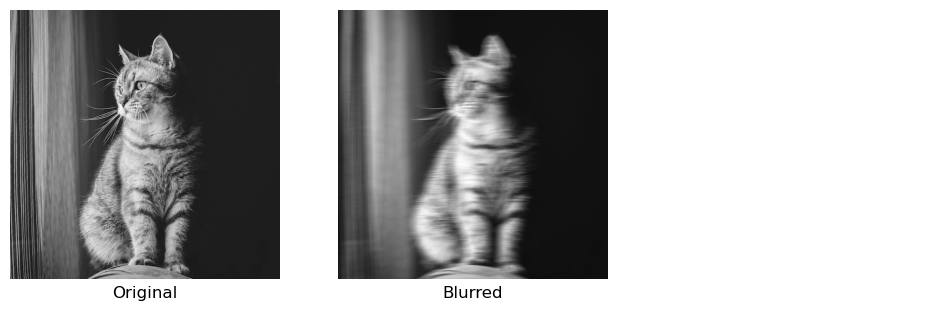

In [4]:
# Example 1 - Image Credit: Image by Arturo Anez from Pixabay

ex1_gray_arr = convert_img_to_norm_np_arr('./motion_deblur_img/input/Image_by_Arturo_Anez_from_Pixabay.jpg',
                      'ex1_grayscale.jpg',
                      grayscale=True)

ex1_psf = build_horizontal_motion_psf(20, ex1_gray_arr.shape)

# Ref: Hansen et al.(2006), Chapter 4.2.2 - Computations with BCCB Matrices (p.44)
ex1_blurred = np.real(np.fft.ifft2(np.fft.fft2(ex1_psf) * np.fft.fft2(ex1_gray_arr)))

fig, sub = plt.subplots(1, 3, figsize=(12, 3.5))
[s.axis('off') for s in sub]

sub[0].imshow(ex1_gray_arr, cmap='gray')
sub[0].set_title('Original', y = -0.1)
sub[1].imshow(ex1_blurred, cmap='gray')
sub[1].set_title('Blurred', y = -0.1)

plt.show()